Ridge Coefficient: [43.57809123]
Lasso Coefficient: [44.12190219]


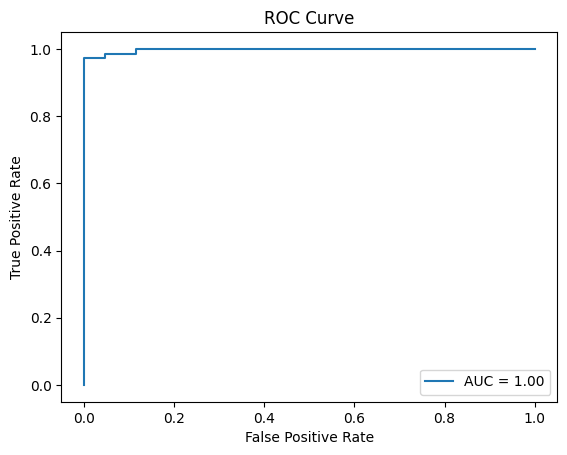

Cross Validation Scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Average CV Score: 0.9507995652848935


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LinearRegression

# ---------------------------
# Regression Dataset
# ---------------------------

X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Ridge Coefficient:", ridge.coef_)
print("Lasso Coefficient:", lasso.coef_)

# Polynomial Regression
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_model.fit(X_train, y_train)

# ---------------------------
# Logistic Regression + ROC
# ---------------------------

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# ROC Curve
y_prob = log_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Cross Validation
scores = cross_val_score(log_model, X, y, cv=5)
print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())